In [1]:
# clearly indicate packages used throughout the notebook
import numpy as np
np.random.seed(70103)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.spatial.distance import euclidean
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Problem 1

## 1

In [2]:
# count vectorization for sentence
sentence = ['to be or not to be']
vectorizer = CountVectorizer()
sentence_vector = vectorizer.fit_transform(sentence).toarray()

# display result
print('count vectorization for the sentence "to be or not to be":')
print(sentence_vector)

count vectorization for the sentence "to be or not to be":
[[2 1 1 2]]


## 2

In [3]:
# count vectorization for query
query = ['be']
query_vector = vectorizer.transform(query).toarray()

# display result
print('count vectorization for the query "be":')
print(query_vector)

count vectorization for the query "be":
[[1 0 0 0]]


In [4]:
# calculate Euclidean distance between query vector and sentence vector
sentence_vector_flat = sentence_vector.flatten()
query_vector_flat = query_vector.flatten()
distance = euclidean(query_vector_flat, sentence_vector_flat)

# display result
print("Euclidean distance between the query and the sentence:")
print(distance)

Euclidean distance between the query and the sentence:
2.6457513110645907


## 3

In [5]:
# cosine similarity between D1 and D2
D1 = ['Taj Mahal is a tourist place in India']
D2 = ['Great Wall of China is a tourist place in China']
X = vectorizer.fit_transform([D1[0], D2[0]])
D1_vector = X[0].toarray()
D2_vector = X[1].toarray()
cosine_sim = cosine_similarity(D1_vector, D2_vector)

# display result
print('cosine similarity between D1 and D2:')
print(cosine_sim[0][0])

cosine similarity between D1 and D2:
0.4558423058385518


# Problem 2

## 1

In [6]:
text = """
Junkfood – Food that do no good to our body. And there’s no need of them in our body
but still we willingly eat them because they are great in taste and easy to cook or ready to
eat. Junk foods have no or very less nutritional value and irrespective of the way they are
marketed, they are not healthy to consume.The only reason of their gaining popularity and
increased trend of consumption is that they are ready to eat or easy to cook foods. People,
of all age groups are moving towards Junkfood as it is hassle free and often ready to grab
and eat. Cold drinks, chips, noodles, pizza, burgers, French fries etc. are few examples from
the great variety of junk food available in the market. Junkfood is the most dangerous food
ever but it is pleasure in eating and it gives a great taste in mouth examples of Junkfood
are kurkure and chips.. cold rings are also source of junk food... they shud nt be ate in high
amounts as it results fatal to our body... it cn be eated in a limited extend ... in research its
found tht ths junk foods r very dangerous fr our health Junkfood is very harmful that is slowly
eating away the health of the present generation. The term itself denotes how dangerous it is
for our bodies. Most importantly, it tastes so good that people consume it on a daily basis.
However, not much awareness is spread about the harmful effects of Junkfood . The problem
is more serious than you think. Various studies show that Junkfood impacts our health
negatively. They contain higher levels of calories, fats, and sugar. On the contrary, they
have very low amounts of healthy nutrients and lack dietary fibers. Parents must discourage
their children from consuming junk food because of the ill effects it has on one’s health.
Junkfood is the easiest way to gain unhealthy weight. The amount of fats and sugar in the
food makes you gain weight rapidly. However, this is not a healthy weight. It is more of
fats and cholesterol which will have a harmful impact on your health. Junk food is also one
of the main reasons for the increase in obesity nowadays. This food only looks and tastes
good, other than that, it has no positive points. The amount of calorie your body requires
to stay fit is not fulfilled by this food. For instance, foods like French fries, burgers, candy,
and cookies, all have high amounts of sugar and fats. Therefore, this can result in long-term
illnesses like diabetes and high blood pressure. This may also result in kidney failure.
"""

# get word counts excluding stop words and sort by frequency
vectorizer = CountVectorizer(stop_words='english')
text_vector = vectorizer.fit_transform([text]).toarray()
word_counts = zip(vectorizer.get_feature_names_out(), text_vector.sum(axis=0))
word_counts = sorted(word_counts, key=lambda x: x[1], reverse=True)

# display result
top_10_words = word_counts[:10]
print('top 10 most common words excluding stop words:')
for word, count in top_10_words:
    print(f'{word}: {count}')

top 10 most common words excluding stop words:
food: 9
junkfood: 8
junk: 6
health: 5
body: 4
eat: 4
fats: 4
foods: 4
amounts: 3
dangerous: 3


## 2

In [7]:
# TF-IDF matrix
documents = [
    'Painting is a hobby of mine',
    'My hobby is coin collection',
    'I do some Painting every now and then'
]
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(documents)

# display result as pandas DataFrame for better readability
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print('TF-IDF matrix:')
print(tfidf_df)

TF-IDF matrix:
        and      coin  collection        do     every     hobby        is  \
0  0.000000  0.000000    0.000000  0.000000  0.000000  0.393511  0.393511   
1  0.000000  0.490479    0.490479  0.000000  0.000000  0.373022  0.373022   
2  0.389888  0.000000    0.000000  0.389888  0.389888  0.000000  0.000000   

      mine        my       now       of  painting      some      then  
0  0.51742  0.000000  0.000000  0.51742  0.393511  0.000000  0.000000  
1  0.00000  0.490479  0.000000  0.00000  0.000000  0.000000  0.000000  
2  0.00000  0.000000  0.389888  0.00000  0.296520  0.389888  0.389888  


# Problem 3

## 1

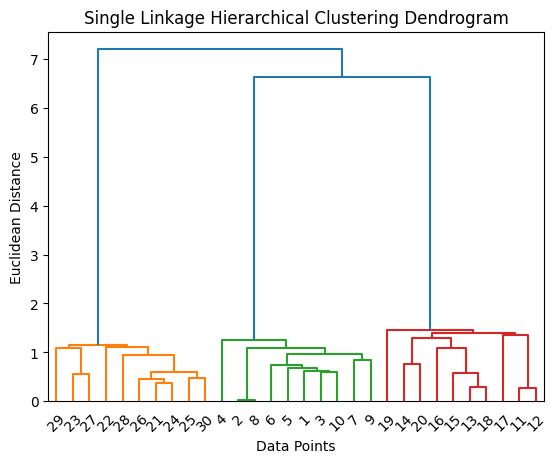

In [8]:
# generate 10 points from each of the following Gaussian distributions
# N([0, 0], I_{2×2})
points_1 = np.random.multivariate_normal([0, 0], np.eye(2), 10)
# N([10, 0], I_{2×2})
points_2 = np.random.multivariate_normal([10, 0], np.eye(2), 10)
# N([0, 10], I_{2×2})
points_3 = np.random.multivariate_normal([0, 10], np.eye(2), 10)

# single linkage hierarchical clustering using Euclidean distance
points = np.vstack((points_1, points_2, points_3))
linked = linkage(points, method='single', metric='euclidean')

# display result as dendrogram
plt.figure()
dendrogram(linked, labels=np.arange(1, 31))
plt.title('Single Linkage Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

## 2

In [9]:
# Load data
reviews_df = pd.read_csv('Reviews.csv')
reviews_df = reviews_df[['Text', 'Score']]

# create binary label
# 1 (Score >= 4); 0 (Score <= 2); drop Score = 3
reviews_df = reviews_df[reviews_df['Score'] != 3]
reviews_df['label'] = reviews_df['Score'].apply(lambda x: 1 if x >= 4 else 0)

# create pipeline for text vectorization and classification
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('classifier', LogisticRegression())
])

# split data and train model
X_train, X_test, y_train, y_test = train_test_split(reviews_df['Text'], reviews_df['label'], test_size=0.2)
pipeline.fit(X_train, y_train)

# evaluate model accuracy on test set
y_pred = pipeline.predict(X_test)
print(f'model accuracy: {accuracy_score(y_test, y_pred)}\n')

def predict_sentiment(text):
    proba = pipeline.predict_proba([text])[0]
    sentiment = 'positive' if proba[1] >= 0.85 else 'negative' if proba[0] >= 0.85 else 'uncertain'
    return sentiment, proba

# predict on provided text documents
texts_to_test = ['this beef is so nice!', 'this food is awful and terrible!']
for text in texts_to_test:
    sentiment, proba = predict_sentiment(text)
    print(f'text document: "{text}"')
    print(f'predicted sentiment: {sentiment} (probabilities: [{proba[0]:.4f}, {proba[1]:.4f}])\n')

model accuracy: 0.929699609178133

text document: "this beef is so nice!"
predicted sentiment: positive (probabilities: [0.0122, 0.9878])

text document: "this food is awful and terrible!"
predicted sentiment: negative (probabilities: [0.9999, 0.0001])

